In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sid321axn/gold-price-prediction-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kl;djfgs
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sid321axn/gold-price-prediction-dataset


100%|██████████| 371k/371k [00:00<00:00, 657MB/s]

In [ ]:
import pandas as pd


In [ ]:
import sklearn
import tensorflow as tf
from tensorflow import keras

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np


In [ ]:
df = pd.read_csv("/content/gold-price-prediction-dataset/FINAL_USO.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718 entries, 0 to 1717
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1718 non-null   object 
 1   Open           1718 non-null   float64
 2   High           1718 non-null   float64
 3   Low            1718 non-null   float64
 4   Close          1718 non-null   float64
 5   Adj Close      1718 non-null   float64
 6   Volume         1718 non-null   int64  
 7   SP_open        1718 non-null   float64
 8   SP_high        1718 non-null   float64
 9   SP_low         1718 non-null   float64
 10  SP_close       1718 non-null   float64
 11  SP_Ajclose     1718 non-null   float64
 12  SP_volume      1718 non-null   int64  
 13  DJ_open        1718 non-null   float64
 14  DJ_high        1718 non-null   float64
 15  DJ_low         1718 non-null   float64
 16  DJ_close       1718 non-null   float64
 17  DJ_Ajclose     1718 non-null   float64
 18  DJ_volum

In [ ]:
print(df["Date"])

0       2011-12-15
1       2011-12-16
2       2011-12-19
3       2011-12-20
4       2011-12-21
           ...    
1713    2018-12-24
1714    2018-12-26
1715    2018-12-27
1716    2018-12-28
1717    2018-12-31
Name: Date, Length: 1718, dtype: object


In [ ]:
df.drop(columns = ["Open",'High',"Low","Close"], inplace=True)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
corelation_Matrix = df.corr()
print(corelation_Matrix)

               Adj Close    Volume   SP_open   SP_high    SP_low  SP_close  \
Adj Close       1.000000  0.246778 -0.684618 -0.684904 -0.683750 -0.684284   
Volume          0.246778  1.000000 -0.218726 -0.216355 -0.223317 -0.220631   
SP_open        -0.684618 -0.218726  1.000000  0.999792  0.999642  0.999461   
SP_high        -0.684904 -0.216355  0.999792  1.000000  0.999511  0.999655   
SP_low         -0.683750 -0.223317  0.999642  0.999511  1.000000  0.999749   
...                  ...       ...       ...       ...       ...       ...   
USO_High        0.635311  0.083064 -0.774626 -0.775482 -0.773550 -0.774799   
USO_Low         0.634732  0.080475 -0.771235 -0.772154 -0.770087 -0.771396   
USO_Close       0.635675  0.081642 -0.773099 -0.773957 -0.771928 -0.773159   
USO_Adj Close   0.635675  0.081642 -0.773099 -0.773957 -0.771928 -0.773159   
USO_Volume     -0.456193  0.069580  0.375568  0.377996  0.371390  0.374658   

               SP_Ajclose  SP_volume   DJ_open   DJ_high  ...  

In [ ]:
base_features = [
    "SP_Ajclose",
    "GDX_Adj Close",
    "USDI_Price",
    "USB_Price",
    "USO_Adj Close",
    "SF_Price", "PLT_Price", "PLD_Price", "RHO_PRICE"]

X = df[base_features].copy()
y = df["Adj Close"].copy()

In [ ]:
X

,SP_Ajclose,GDX_Adj Close,USDI_Price,USB_Price,USO_Adj Close,SF_Price,PLT_Price,PLD_Price,RHO_PRICE
Date,,,,,,,,,
2011-12-15,105.441238,48.973877,80.341,1.911,36.130001,53604,1414.65,618.85,1425
2011-12-16,105.597549,49.921513,80.249,1.851,36.270000,53458,1420.25,623.65,1400
2011-12-19,104.468536,48.490578,80.207,1.810,36.200001,52961,1411.10,608.80,1400
2011-12-20,107.629784,50.215282,80.273,1.927,37.560001,53487,1434.75,626.65,1400
2011-12-21,107.838242,50.186852,80.350,1.970,38.110001,53148,1429.05,635.90,1400
...,...,...,...,...,...,...,...,...,...
2018-12-24,234.339996,21.090000,96.007,2.736,9.290000,37541,788.40,1172.80,2480
2018-12-26,246.179993,20.620001,96.568,2.810,9.900000,38253,799.25,1190.10,2480
2018-12-27,248.070007,20.969999,96.001,2.774,9.620000,38690,795.50,1196.00,2470


In [ ]:
y

,Adj Close
Date,
2011-12-15,152.330002
2011-12-16,155.229996
2011-12-19,154.869995
2011-12-20,156.979996
2011-12-21,157.160004
...,...
2018-12-24,120.019997
2018-12-26,119.660004
2018-12-27,120.570000


In [ ]:
df["gold_lag_1" ] = df["Adj Close"].shift(1)
df["gold_lag_5" ] = df["Adj Close"].shift(5)
df["gold_lag_10"] = df["Adj Close"].shift(10)
df["gold_lag_15"] = df["Adj Close"].shift(15)
df["gold_lag_20"] = df["Adj Close"].shift(20)

lag = [
    "gold_lag_1",
    "gold_lag_5",
    "gold_lag_10",
    "gold_lag_15",
    "gold_lag_20"
]

X = df[base_features + lag].copy()
y = df["Adj Close"].copy()

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1718 entries, 2011-12-15 to 2018-12-31
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SP_Ajclose     1718 non-null   float64
 1   GDX_Adj Close  1718 non-null   float64
 2   USDI_Price     1718 non-null   float64
 3   USB_Price      1718 non-null   float64
 4   USO_Adj Close  1718 non-null   float64
 5   SF_Price       1718 non-null   int64  
 6   PLT_Price      1718 non-null   float64
 7   PLD_Price      1718 non-null   float64
 8   RHO_PRICE      1718 non-null   int64  
 9   gold_lag_1     1717 non-null   float64
 10  gold_lag_5     1713 non-null   float64
 11  gold_lag_10    1708 non-null   float64
 12  gold_lag_15    1703 non-null   float64
 13  gold_lag_20    1698 non-null   float64
dtypes: float64(12), int64(2)
memory usage: 201.3 KB


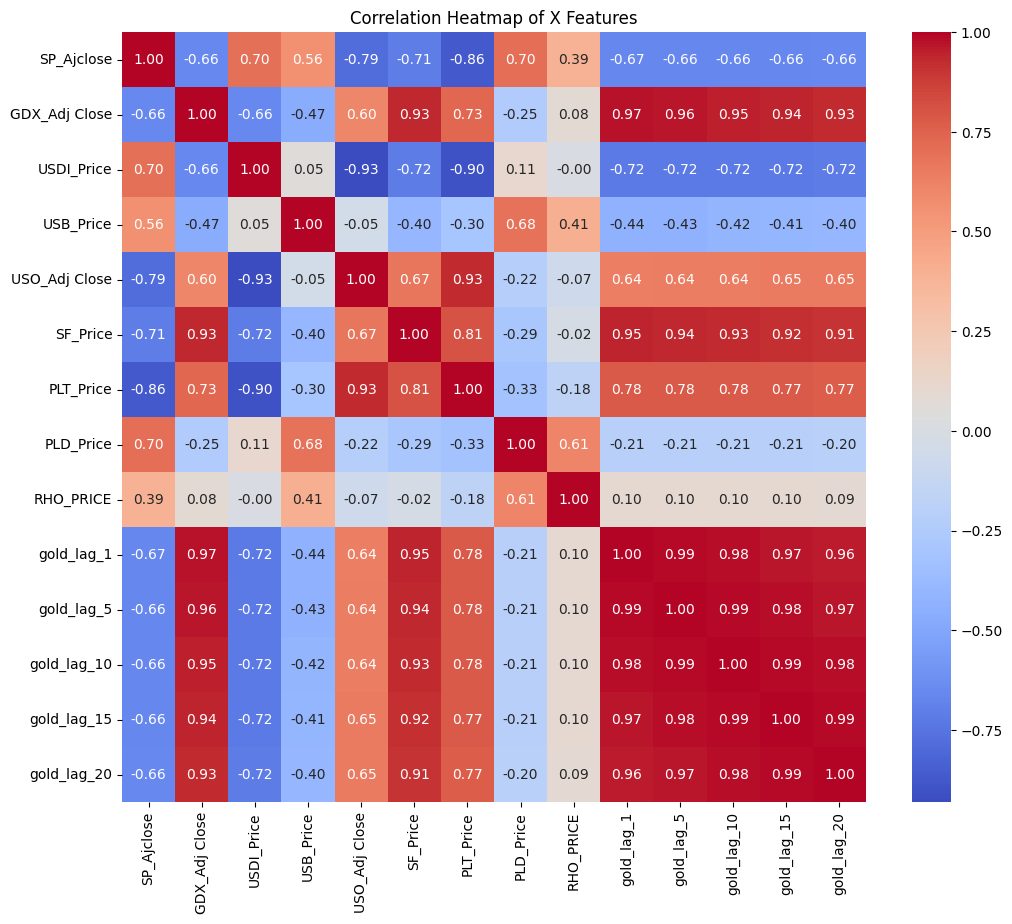

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the features in X
correlation_matrix_X = X.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_X, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of X Features')
plt.show()

In [ ]:
correlation_matrix_X

,SP_Ajclose,GDX_Adj Close,USDI_Price,USB_Price,USO_Adj Close,SF_Price,PLT_Price,PLD_Price,RHO_PRICE,gold_lag_1,gold_lag_5,gold_lag_10,gold_lag_15,gold_lag_20
SP_Ajclose,1.000000,-0.657799,0.697188,0.559923,-0.785103,-0.708038,-0.864895,0.701170,0.393247,-0.665735,-0.664402,-0.662342,-0.660199,-0.658679
GDX_Adj Close,-0.657799,1.000000,-0.658763,-0.465313,0.600756,0.934367,0.734653,-0.250554,0.082225,0.972522,0.963464,0.952420,0.942167,0.931580
USDI_Price,0.697188,-0.658763,1.000000,0.050497,-0.930767,-0.719465,-0.901038,0.113176,-0.001144,-0.721538,-0.721127,-0.720393,-0.719730,-0.719387
USB_Price,0.559923,-0.465313,0.050497,1.000000,-0.047223,-0.402075,-0.302701,0.683238,0.407982,-0.438753,-0.429084,-0.417111,-0.406115,-0.397463
USO_Adj Close,-0.785103,0.600756,-0.930767,-0.047223,1.000000,0.671612,0.930607,-0.218673,-0.068746,0.636448,0.639723,0.644121,0.647853,0.651604
SF_Price,-0.708038,0.934367,-0.719465,-0.402075,0.671612,1.000000,0.808133,-0.289833,-0.022740,0.946088,0.938241,0.926874,0.915846,0.906122
PLT_Price,-0.864895,0.734653,-0.901038,-0.302701,0.930607,0.808133,1.000000,-0.326248,-0.176380,0.776068,0.776587,0.775431,0.773888,0.770849
PLD_Price,0.701170,-0.250554,0.113176,0.683238,-0.218673,-0.289833,-0.326248,1.000000,0.612363,-0.212651,-0.210719,-0.209259,-0.207019,-0.204584
RHO_PRICE,0.393247,0.082225,-0.001144,0.407982,-0.068746,-0.022740,-0.176380,0.612363,1.000000,0.095395,0.095858,0.097472,0.095518,0.094163
gold_lag_1,-0.665735,0.972522,-0.721538,-0.438753,0.636448,0.946088,0.776068,-0.212651,0.095395,1.000000,0.990937,0.979638,0.967785,0.956266


In [ ]:
from sklearn.model_selection import train_test_split

X.dropna(inplace=True)
y = y[X.index]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the StandardScaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Transform the test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print(f"X_train scaled shape: {X_train_scaled.shape}")
print(f"X_test scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train scaled shape: (1358, 14)
X_test scaled shape: (340, 14)
y_train shape: (1358,)
y_test shape: (340,)


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

model = SVR(kernel='rbf')
model.fit(X_train_scaled, y_train)

SVR()

In [ ]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 2.5577118821399747
R-squared: 0.9915890071934249


The results show a Mean Squared Error (MSE) of approximately 0.9915 and an R-squared value of 0.995.

 An R-squared of 0.995 is quite good, indicating
 **the model explains about 99.5% of the variance in the gold prices**.

  The MSE tells us the average squared difference between the predicted and actual values. Taking the square root of the MSE gives us the Root Mean Squared Error (RMSE) of around , meaning that, on average,

  **predictions are off by about $2.5**